In [1]:
import pandas as pd

In [2]:
import json

In [4]:
flights_df = pd.read_json("flights.json")

In [5]:
hotels_df = pd.read_json("hotels.json")

In [6]:
places_df = pd.read_json("places.json")

In [7]:
print(flights_df.head())
print(hotels_df.head())
print(places_df.head())


  flight_id    airline       from         to      departure_time  \
0    FL0001     IndiGo  Hyderabad      Delhi 2025-01-04 11:32:00   
1    FL0002  Air India      Delhi    Kolkata 2025-11-26 05:34:00   
2    FL0003   SpiceJet    Chennai  Hyderabad 2025-06-03 00:26:00   
3    FL0004  Air India  Bangalore     Mumbai 2025-05-13 13:18:00   
4    FL0005  Air India    Chennai  Bangalore 2025-02-08 03:08:00   

         arrival_time  price  
0 2025-01-04 15:32:00   2907  
1 2025-11-26 09:34:00   3779  
2 2025-06-03 01:26:00   5473  
3 2025-05-13 17:18:00   4764  
4 2025-02-08 05:08:00   3695  
  hotel_id                name   city  stars  price_per_night  \
0  HOT0001  Grand Palace Hotel  Delhi      4             3897   
1  HOT0002      Comfort Suites  Delhi      5             3650   
2  HOT0003   Green Leaf Resort  Delhi      4             6123   
3  HOT0004       Sunrise Hotel  Delhi      2             4783   
4  HOT0005  Blue Lagoon Resort  Delhi      2             2743   

              

In [8]:
print(flights_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       30 non-null     object        
 1   airline         30 non-null     object        
 2   from            30 non-null     object        
 3   to              30 non-null     object        
 4   departure_time  30 non-null     datetime64[ns]
 5   arrival_time    30 non-null     datetime64[ns]
 6   price           30 non-null     int64         
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 1.8+ KB
None


In [9]:
print(flights_df.isnull().sum())

flight_id         0
airline           0
from              0
to                0
departure_time    0
arrival_time      0
price             0
dtype: int64


In [10]:
print(flights_df.describe())


             price
count    30.000000
mean   5510.866667
std    1758.539240
min    2792.000000
25%    4088.750000
50%    5422.000000
75%    6760.250000
max    8981.000000


In [11]:
flights_df.sort_values('price', ascending=False).head(5)  # Top 5 expensive flights
flights_df.sort_values('price').head(5)                  # Top 5 cheap flights


,flight_id,airline,from,to,departure_time,arrival_time,price
17,FL0018,Go First,Mumbai,Hyderabad,2025-09-22 18:45:00,2025-09-22 19:45:00,2792
0,FL0001,IndiGo,Hyderabad,Delhi,2025-01-04 11:32:00,2025-01-04 15:32:00,2907
14,FL0015,Air India,Hyderabad,Kolkata,2025-05-22 22:32:00,2025-05-23 00:32:00,2909
23,FL0024,SpiceJet,Mumbai,Goa,2025-07-15 14:38:00,2025-07-15 18:38:00,3304
4,FL0005,Air India,Chennai,Bangalore,2025-02-08 03:08:00,2025-02-08 05:08:00,3695


In [12]:
flights_df.groupby('airline')['price'].mean()


airline
Air India    5119.900000
Go First     5625.200000
IndiGo       4889.333333
SpiceJet     5960.500000
Vistara      8981.000000
Name: price, dtype: float64

In [14]:
flights_df['from'].value_counts()


Bangalore    6
Goa          6
Jaipur       5
Hyderabad    4
Chennai      3
Delhi        2
Kolkata      2
Mumbai       2
Name: from, dtype: int64

In [15]:
hotels_df['stars'].value_counts()


2    14
5    11
4     9
3     6
Name: stars, dtype: int64

In [16]:
places_df[places_df['city'] == 'Mumbai']


,place_id,name,city,type,rating
5,PLC0006,Famous Museum,Mumbai,park,3.8
6,PLC0007,Beautiful Fort,Mumbai,park,3.9
7,PLC0008,Historic Temple,Mumbai,fort,3.7
8,PLC0009,Famous Lake,Mumbai,beach,4.3
9,PLC0010,Famous Fort,Mumbai,market,3.6


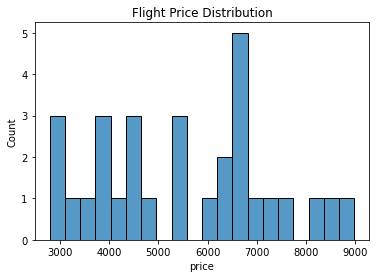

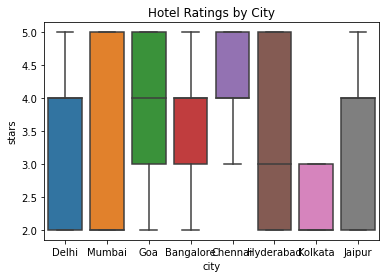

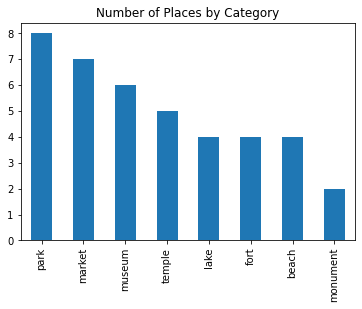

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flight price distribution
sns.histplot(flights_df['price'], bins=20)
plt.title('Flight Price Distribution')
plt.show()

# Hotel ratings by city
sns.boxplot(x='city', y='stars', data=hotels_df)
plt.title('Hotel Ratings by City')
plt.show()

# Count of places by category
places_df['type'].value_counts().plot(kind='bar')
plt.title('Number of Places by Category')
plt.show()


In [23]:
flights_df.groupby(['from','to'])['price'].mean().sort_values().head(10)


from       to       
Mumbai     Hyderabad    2792.0
Hyderabad  Delhi        2907.0
           Kolkata      2909.0
Mumbai     Goa          3304.0
Chennai    Bangalore    3695.0
Bangalore  Kolkata      3835.0
Chennai    Mumbai       4013.0
Kolkata    Jaipur       4328.0
Jaipur     Kolkata      4372.0
Bangalore  Mumbai       4764.0
Name: price, dtype: float64

<AxesSubplot:xlabel='hour', ylabel='price'>

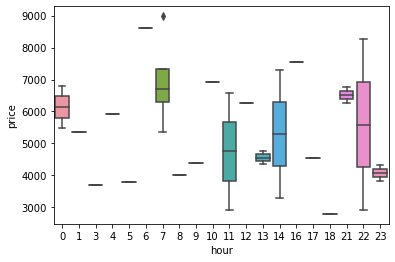

In [24]:
flights_df['hour'] = flights_df['departure_time'].dt.hour
sns.boxplot(x='hour', y='price', data=flights_df)


In [27]:
hotels_df['value_score'] = hotels_df['stars'] / hotels_df['price_per_night']
hotels_df.sort_values('value_score', ascending=False).head(10)


,hotel_id,name,city,stars,price_per_night,amenities,value_score
13,HOT0014,Royal Heritage,Goa,5,1232,"[wifi, parking, breakfast, pool]",0.004058
24,HOT0025,Budget Stay Inn,Chennai,4,1312,"[pool, breakfast, spa]",0.003049
21,HOT0022,Grand Palace Hotel,Chennai,4,1733,"[breakfast, spa, wifi, parking]",0.002308
14,HOT0015,Budget Stay Inn,Goa,4,2248,"[wifi, spa, pool, gym]",0.001779
10,HOT0011,Comfort Suites,Goa,5,2828,"[spa, pool, wifi, gym]",0.001768
1,HOT0002,Comfort Suites,Delhi,5,3650,"[gym, breakfast, wifi, parking]",0.001370
39,HOT0040,Sea View Resort,Jaipur,5,3673,"[breakfast, parking, pool]",0.001361
5,HOT0006,Green Leaf Resort,Mumbai,2,1471,"[gym, parking, pool]",0.001360
11,HOT0012,Green Leaf Resort,Goa,3,2357,"[spa, gym, pool, breakfast]",0.001273
38,HOT0039,Grand Palace Hotel,Jaipur,4,3293,"[gym, wifi, breakfast, spa, pool]",0.001215


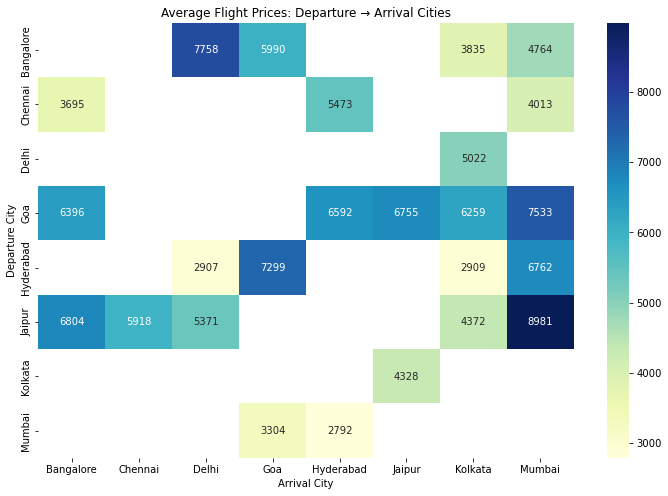

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppose flights_df has columns: departure_city, arrival_city, price

# Create pivot table for heatmap
price_matrix = flights_df.pivot_table(index='from',
                                      columns='to',
                                      values='price',
                                      aggfunc='mean')  # average price

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(price_matrix, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Flight Prices: Departure → Arrival Cities")
plt.xlabel("Arrival City")
plt.ylabel("Departure City")
plt.show()


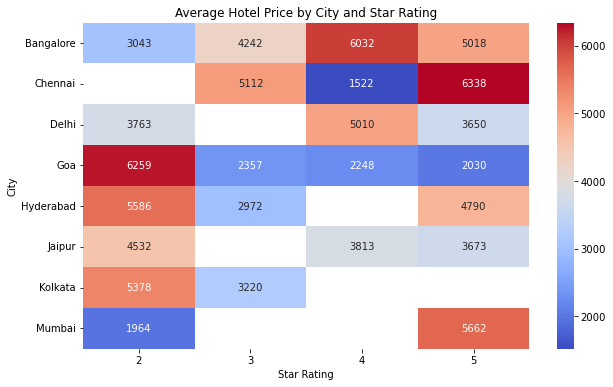

In [30]:
# Pivot table: rows = city, columns = star rating, values = average price
hotel_matrix = hotels_df.pivot_table(index='city', 
                                    columns='stars', 
                                    values='price_per_night', 
                                    aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(hotel_matrix, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Average Hotel Price by City and Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("City")
plt.show()
